# Training the RL Agent using AutoREC

This notebook walks through training a DDQN agent to discover equivalent circuit models from EIS data.

## What You'll Learn
1. Two ways to train: direct instantiation vs config-based
2. Understanding agent and environment setup
3. Training workflow and checkpoints
4. Monitoring training progress
5. Saving and loading models

## Prerequisites
- Completed data preparation (see 01_data_preparation_walkthrough.ipynb)
- Have a processed dataset pickle file

In [1]:
# Configure threading (important for stability)
from autorec.runtime import configure_autorec_runtime

configure_autorec_runtime(thread_count=1, warmup_autoeis=True)
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = (
    "3"  # Suppress TensorFlow logging (1: INFO, 2: WARNING, 3: ERROR) - example: you are using different TensorFlow than the trained model you are loading
)

# Imports
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from autorec.utils import set_global_seed

# Set global seed for reproducibility
set_global_seed(42, deterministic_ops=True)

from autorec.data_preparation import EISDataPrep
from autorec.environment import EIS_ECM_Env
from autorec.agent import DDQN_ECM
from autorec.factory import environment_and_agent_builder

I0000 00:00:1786719152.576297   10306 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786719155.044678   10306 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Global seed set to 42
Deterministic operations: True


---
## Step 1: Load Data

First, we need our prepared EIS dataset.

In [2]:
# Load prepared dataset
data_prep = EISDataPrep(path="../data/examples/training_dataset.pkl", evaluation=True)

dataset = data_prep.load()
print(f"Loaded {len(dataset)} EIS measurements")
print(data_prep.get_summary())


Validation Warnings:
  ⚠ Dataset contains extra columns (will be ignored): Z_perfect, Z_perfect_flatten, chi_LinKK, r2_LinKK, chi_fit, r2_fit, true_state
  ⚠ Column 'sub_id' should contain string values

✓ Validation passed (1350 samples)
Loaded 1350 EIS measurements
DATASET SUMMARY
Mode: load
Evaluation Mode: True
Path: ../data/examples/training_dataset.pkl
Total samples: 1350

Columns: ['sub_id', 'true_circuit', 'Z_perfect', 'Z_perfect_flatten', 'Z_true', 'chi_LinKK', 'r2_LinKK', 'chi_fit', 'r2_fit', 'chi_thresh', 'r2_thresh', 'true_state', 'freq', 'flatten_Z']

Data types:
sub_id                 int64
true_circuit          object
Z_perfect             object
Z_perfect_flatten     object
Z_true                object
chi_LinKK            float64
r2_LinKK             float64
chi_fit               object
r2_fit               float64
chi_thresh            object
r2_thresh            float64
true_state            object
freq                  object
flatten_Z             object
dtype: obj

---
## Method 1: Direct Instantiation (Good for Learning)

This approach creates the environment and agent directly in code. It's more explicit and easier to understand when learning.

### Create the Environment

The environment handles:
- Sampling EIS measurements from the dataset
- Managing circuit representations (GEP chromosomes)
- Evaluating circuit fitness (Use caching for speedup)
- Calculating rewards

In [3]:
# Create environment
env = EIS_ECM_Env(
    dataset=dataset,  # The EIS measurements
    seed=42,  # Random seed
    chromosome_HEAD_len=10,  # Circuit complexity (longer = more complex circuits possible)
    cache_enabled=True,  # HIGHLY RECOMMENDED - speeds up training 10-50x
)

print("Environment created!")
print(f"  Chromosome length: {env.chromosome_HEAD_len + env.chromosome_TAIL_len}")
print(f"  Available elements: {env.ELEMENTS}")
print(f"  Caching enabled: {env.cache_enabled if hasattr(env, 'cache') else 'N/A'}")

✓ Circuit evaluation cache enabled: LRU with capacity 20,000
Environment created!
  Chromosome length: 21
  Available elements: ['+', '/', 'R', 'L', 'P']
  Caching enabled: True


### Understanding Circuit Representation

Circuits are encoded as GEP (Gene Expression Programming) strings:

- `+` = series connection
- `/` = parallel connection  
- `R` = resistor
- `L` = inductor
- `P` = constant phase element
- `C` = Capacitor

Example: `+/RPRRRR` = R in series with (P parallel to R) - Note: In this example, the last three R are not part of the circuits as they are the non-coding part of chromosome

The chromosome is split into:
- **HEAD**: Can contain any element (+, /, R, L, C, P)
- **TAIL**: Only terminal elements (R, L, C, P)



### Create the Agent

The DDQN agent includes:
- Neural network to predict action values
- Experience replay buffer
- Epsilon-greedy exploration strategy
- Target network for stable learning

In [4]:
# Calculate action space size
action_cap = env.chromosome_HEAD_len + env.chromosome_TAIL_len + 3

DIR = "./demo_output"  # Directory where the output will be saved for this demo

# Create agent
agent = DDQN_ECM(
    training_env=env,
    action_cap=action_cap,  # Max actions per episode
    num_trials=50,  # Start small for testing (use 8000+ for real training)
    save_dir=DIR,
    save_frequency=100,  # Save checkpoint every 100 trials
    # RL hyperparameters (using defaults, can customize)
    gamma=0.99,  # Discount factor
    learning_rate=0.0005,
    batch_size=150,
    buffer_capacity=15000,
    initial_epsilon=1.0,  # Start with full exploration
    epsilon_min=0.1,  # End with some exploration
    epsilon_decay=0.99968,
)

print("Agent created!")
print(f"  Action space size: {action_cap}")
print(f"  Neural network input shape: {agent.model.input_shape}")
print(f"  Neural network output shape: {agent.model.output_shape}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 442)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 40)             │        17,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 80)             │         3,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,640 (88.44 KB)

 Trainable params: 22,640 (88.44 KB)

 Non-trainable params: 0 (0.00 B)

Model summary saved to demo_output/model_summary.txt
Agent created!
  Action space size: 24
  Neural network input shape: (None, 442)
  Neural network output shape: (None, 80)


### Train the Agent

Training loop:
1. Reset environment (initial circuit + random EIS)
2. Agent takes actions (mutates circuit)
3. Environment returns reward based on fit quality and circuit complexity
4. Store experience in replay buffer
5. Train neural network on batched experiences
6. Gradually decay epsilon (exploration → exploitation)

**Note**: For a quick demo, we're using 50 trials.  For real training, use 8000+.

Starting training...
This will take some time. Watch for checkpoint saves.

✓ Switched to training environment
Training on: 1350 EIS samples
Trial:  0 for EIS_i: 1106 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Intermediate model saved at trial 0
Trial:  1 for EIS_i: 300 (EIS of R1-[R2-P3,C4])
Trial:  2 for EIS_i: 1182 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  3 for EIS_i: 951 (EIS of R1-[R2,C3]-[R4,C5]-P6)
Trial:  4 for EIS_i: 1015 (EIS of R1-[R2,C3]-[R4,C5]-P6)
Trial:  5 for EIS_i: 1306 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  6 for EIS_i: 1209 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  7 for EIS_i: 1148 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  8 for EIS_i: 604 (EIS of R1-[R2-[R3,C4],C5])
Trial:  9 for EIS_i: 146 (EIS of R1-[R2,C3])
Trial:  10 for EIS_i: 1080 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  11 for EIS_i: 266 (EIS of R1-[R2,C3])
Trial:  12 for EIS_i: 938 (EIS of R1-[R2,C3]-[R4,C5]-P6)
Trial:  13 for EIS_i: 526 (EIS of R1-[R2-P3,C4])
Trial:  14 for EIS_i: 511 (EIS of R1-[R

<string>:1: RuntimeWarning: overflow encountered in reciprocal
<string>:1: RuntimeWarning: invalid value encountered in reciprocal


Trial:  30 for EIS_i: 1269 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  31 for EIS_i: 799 (EIS of R1-[R2-[R3,C4],C5])
Trial:  32 for EIS_i: 294 (EIS of R1-[R2-P3,C4])
Trial:  33 for EIS_i: 485 (EIS of R1-[R2-P3,C4])
Trial:  34 for EIS_i: 41 (EIS of R1-[R2,C3])
Trial:  35 for EIS_i: 347 (EIS of R1-[R2-P3,C4])
Trial:  36 for EIS_i: 121 (EIS of R1-[R2,C3])
Trial:  37 for EIS_i: 1053 (EIS of R1-[R2,C3]-[R4,C5]-P6)
Trial:  38 for EIS_i: 1191 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  39 for EIS_i: 1319 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  40 for EIS_i: 640 (EIS of R1-[R2-[R3,C4],C5])
Trial:  41 for EIS_i: 1045 (EIS of R1-[R2,C3]-[R4,C5]-P6)
Trial:  42 for EIS_i: 1108 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  43 for EIS_i: 606 (EIS of R1-[R2-[R3,C4],C5])
Trial:  44 for EIS_i: 305 (EIS of R1-[R2-P3,C4])
Trial:  45 for EIS_i: 305 (EIS of R1-[R2-P3,C4])
Trial:  46 for EIS_i: 569 (EIS of R1-[R2-[R3,C4],C5])
Trial:  47 for EIS_i: 263 (EIS of R1-[R2,C3])
Trial:  48 for EIS_i: 202 (EIS of 

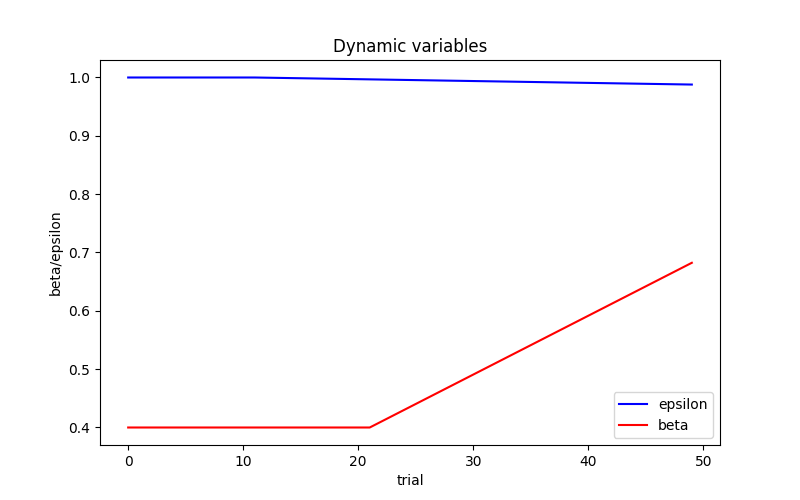

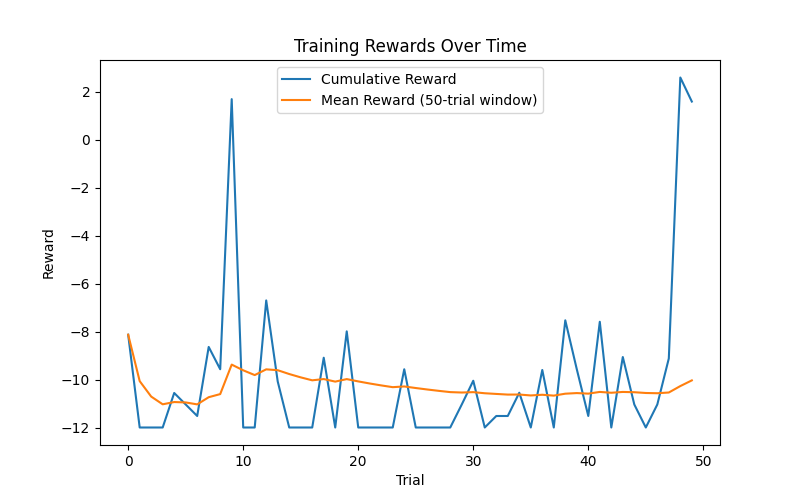

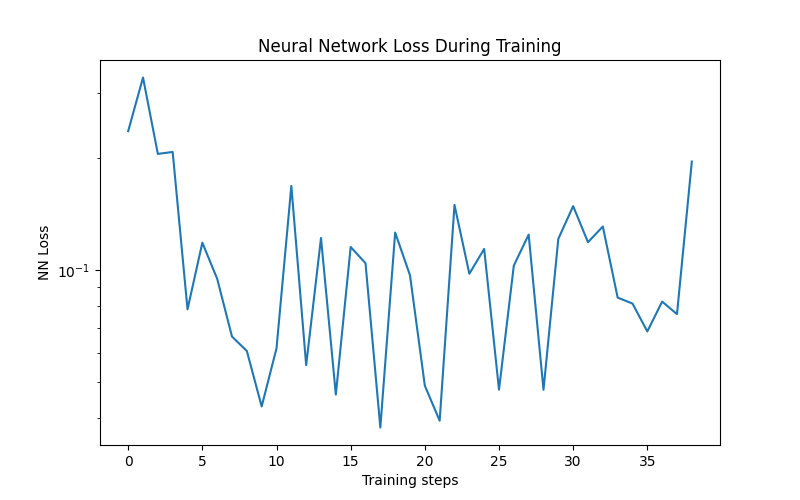


✓ Training complete!


In [5]:
# Train!
print("Starting training...")
print("This will take some time. Watch for checkpoint saves.\n")

training_results = agent.train()

print("\n✓ Training complete!")

### Save the Trained Model

In [6]:
# Save model
model_path = Path(f"{DIR}/models/trained_model.keras")
model_path.parent.mkdir(parents=True, exist_ok=True)

agent.save_model(model_path)
print(f"Model saved to: {model_path}")

Model saved to: demo_output/models/trained_model.keras
Model saved to: demo_output/models/trained_model.keras


---
## Method 2: Config-Based (Recommended for Production)

This approach uses YAML configuration files. It's cleaner and more reproducible.

### Create a Configuration File

Save this as `my_training_config.yaml`:

```yaml
environment:
  dataset_path: "../data/examples/training_dataset.pkl"
  seed: 42
  chromosome_HEAD_len: 10
  cache_enabled: true
  cache_capacity: 20000

agent:
  num_trials: 50
  save_dir: "./demo_output"
  save_frequency: 100
  
  # RL hyperparameters
  hidden_layers:
    - [40, relu]
    - [40, relu]
  gamma: 0.99
  learning_rate: 0.0005
  batch_size: 150
  buffer_capacity: 15000
  
  # Exploration schedule
  initial_epsilon: 1.0
  epsilon_min: 0.1
  epsilon_decay: 0.99968
```

Or use the default config file. Below we are using the default config file

**IMPORTANT:** Items in the configuration file are treated as keyword arguments when instantiating the environment and agent, except for `dataset_path`, which is used in place of the required `dataset` argument for `EIS_ECM_Env`.

In [7]:
# Using the default config file
CONFIG_FILE = "../configs_yaml/examples/demo_environment_agent_config.yaml"

# Build everything from config
print("Building from config...")
env_factory, eval_env, agent_factory = environment_and_agent_builder(CONFIG_FILE)

print("✓ Environment and agent built from config!")

Building from config...
Creating environment(s)...
✓ Circuit evaluation cache enabled: LRU with capacity 20,000
Creating agent...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 442)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 40)             │        17,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 80)             │         3,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,640 (88.44 KB)

 Trainable params: 22,640 (88.44 KB)

 Non-trainable params: 0 (0.00 B)

Model summary saved to demo_output/model_summary.txt
✓ Environment and agent built from config!


Starting training with factory-built agent...

✓ Switched to training environment
Training on: 1350 EIS samples
Trial:  0 for EIS_i: 1106 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Intermediate model saved at trial 0
Trial:  1 for EIS_i: 300 (EIS of R1-[R2-P3,C4])
Trial:  2 for EIS_i: 1182 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  3 for EIS_i: 951 (EIS of R1-[R2,C3]-[R4,C5]-P6)
Trial:  4 for EIS_i: 1015 (EIS of R1-[R2,C3]-[R4,C5]-P6)
Trial:  5 for EIS_i: 1306 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  6 for EIS_i: 1209 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  7 for EIS_i: 1148 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  8 for EIS_i: 604 (EIS of R1-[R2-[R3,C4],C5])
Trial:  9 for EIS_i: 146 (EIS of R1-[R2,C3])
Trial:  10 for EIS_i: 1080 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  11 for EIS_i: 266 (EIS of R1-[R2,C3])
Trial:  12 for EIS_i: 938 (EIS of R1-[R2,C3]-[R4,C5]-P6)
Trial:  13 for EIS_i: 526 (EIS of R1-[R2-P3,C4])
Trial:  14 for EIS_i: 511 (EIS of R1-[R2-P3,C4])
Trial:  15 for EIS_

<string>:1: RuntimeWarning: overflow encountered in reciprocal
<string>:1: RuntimeWarning: invalid value encountered in reciprocal


Trial:  30 for EIS_i: 1269 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  31 for EIS_i: 799 (EIS of R1-[R2-[R3,C4],C5])
Trial:  32 for EIS_i: 294 (EIS of R1-[R2-P3,C4])
Trial:  33 for EIS_i: 485 (EIS of R1-[R2-P3,C4])
Trial:  34 for EIS_i: 41 (EIS of R1-[R2,C3])
Trial:  35 for EIS_i: 347 (EIS of R1-[R2-P3,C4])
Trial:  36 for EIS_i: 121 (EIS of R1-[R2,C3])
Trial:  37 for EIS_i: 1053 (EIS of R1-[R2,C3]-[R4,C5]-P6)
Trial:  38 for EIS_i: 1191 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  39 for EIS_i: 1319 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  40 for EIS_i: 640 (EIS of R1-[R2-[R3,C4],C5])
Trial:  41 for EIS_i: 1045 (EIS of R1-[R2,C3]-[R4,C5]-P6)
Trial:  42 for EIS_i: 1108 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  43 for EIS_i: 908 (EIS of R1-[R2,C3]-[R4,C5]-P6)
Trial:  44 for EIS_i: 505 (EIS of R1-[R2-P3,C4])
Trial:  45 for EIS_i: 1307 (EIS of R1-[R2,C3]-[R4,C5]-[R6,C7])
Trial:  46 for EIS_i: 668 (EIS of R1-[R2-[R3,C4],C5])
Trial:  47 for EIS_i: 257 (EIS of R1-[R2,C3])
Trial:  48 for EI

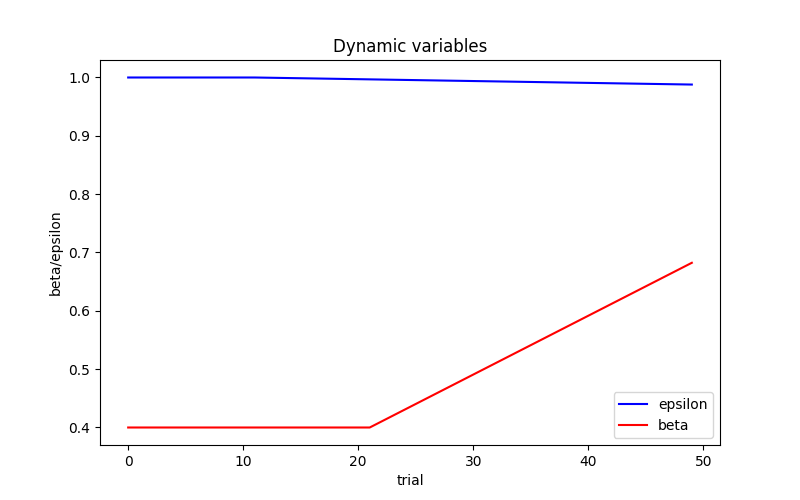

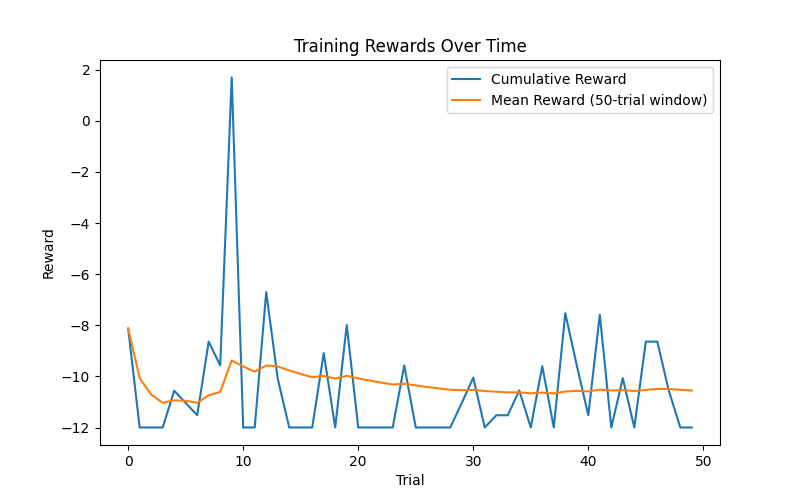

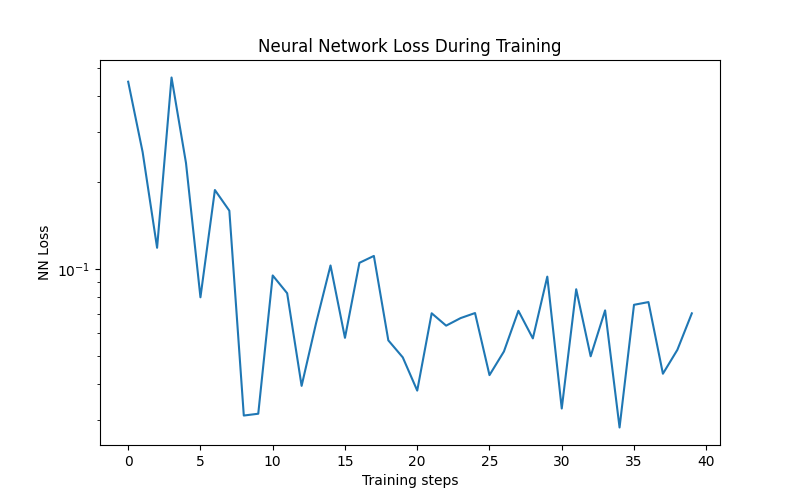


✓ Training complete!


In [8]:
# Train using config-based agent
print("Starting training with factory-built agent...\n")

training_results_factory = agent_factory.train()

print("\n✓ Training complete!")

In [9]:
# Save factory-trained model
model_path_factory = Path(f"{DIR}/training_factory_demo/models/trained_model.keras")
model_path_factory.parent.mkdir(parents=True, exist_ok=True)

agent_factory.save_model(model_path_factory)
print(f"Model saved to: {model_path_factory}")

Model saved to: demo_output/training_factory_demo/models/trained_model.keras
Model saved to: demo_output/training_factory_demo/models/trained_model.keras


---
## Monitoring Training Progress

Let's look at some training metrics (if available from training_results).

In [10]:
# Check what training results contain
if training_results is not None:
    print("Training results available!")
    if isinstance(training_results, dict):
        print(f"Keys: {training_results.keys()}")
    elif isinstance(training_results, pd.DataFrame):
        print(f"Columns: {training_results.columns.tolist()}")
        print(f"Shape: {training_results.shape}")
else:
    print("No training results returned (check agent.train() implementation)")

Training results available!
Keys: dict_keys(['NN_loss', 'success_rate', 'terminal_states', 'statistical_analysis'])


### Epsilon Decay Visualization

Visualize how exploration decreases over training.

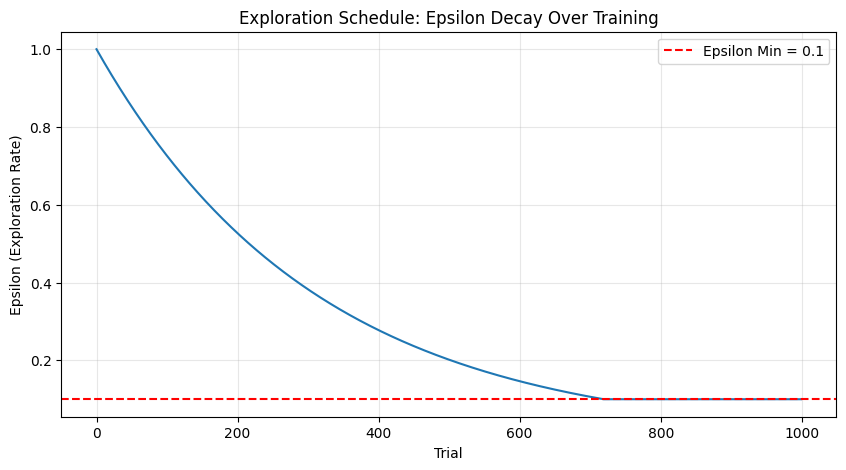

Starting epsilon: 1.0
Final epsilon: 0.0998
Reached epsilon_min: True


In [11]:
# Simulate epsilon decay
num_trials = 1000
initial_epsilon = 1.0
epsilon_min = 0.1
epsilon_decay = 0.9968

epsilons = []
epsilon = initial_epsilon
for trial in range(num_trials):
    epsilons.append(epsilon)
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

plt.figure(figsize=(10, 5))
plt.plot(epsilons)
plt.xlabel("Trial")
plt.ylabel("Epsilon (Exploration Rate)")
plt.title("Exploration Schedule: Epsilon Decay Over Training")
plt.grid(True, alpha=0.3)
plt.axhline(y=epsilon_min, color="r", linestyle="--", label=f"Epsilon Min = {epsilon_min}")
plt.legend()
plt.show()

print(f"Starting epsilon: {initial_epsilon}")
print(f"Final epsilon: {epsilons[-1]:.4f}")
print(f"Reached epsilon_min: {epsilons[-1] <= epsilon_min}")

---
## Loading a Trained Model

To use a previously trained model:

In [12]:
# Load the trained model

agent_loaded = DDQN_ECM(
    training_env=env,
    save_dir=DIR,
    action_cap=action_cap,
    num_trials=500,  # Doesn't matter for loaded models
    model=model_path,
)

print("Agent is ready for evaluation!")

✓ Model loaded from: demo_output/models/trained_model.keras


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 442)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 40)             │        17,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 80)             │         3,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,640 (88.44 KB)

 Trainable params: 22,640 (88.44 KB)

 Non-trainable params: 0 (0.00 B)

Model summary saved to demo_output/model_summary.txt
Agent is ready for evaluation!


---
## Training Tips

### For Quick Testing (Notebooks):
- Use 100-500 trials
- Save checkpoints frequently (every 100 trials)
- Enable caching (mandatory for speed)
- Use smaller dataset if possible

### For Real Training (Production):
- Use 8000+ trials
- Run in script (not notebook) for stability
- Use config files for reproducibility
- Save checkpoints every 500 trials
- Monitor loss/rewards in logs
- Consider distributed training for large datasets

### Hyperparameter Guidelines:
- **learning_rate**: 0.0005 is a good starting point
- **batch_size**: 150-200 works well
- **buffer_capacity**: 15000-20000 for most datasets
- **gamma**: 0.99 (value future rewards highly)
- **epsilon_decay**: Adjust so epsilon reaches min around 60-70% of training

---
## Next Steps

Your model is trained! Move to:
- **03_evaluation_walkthrough.ipynb** for comprehensive evaluation
- Learn how to use the model on new EIS data
- Analyze discovered circuits vs ground truth
- Generate evaluation reports